In [9]:
import duckdb
import pandas as pd
import seaborn as sns
from pprint import pprint

In [10]:
con = duckdb.connect("/home/etienne/projects/inatML/data/inat.duckdb")
df = con.execute("SELECT * FROM raw.downloads").df()
con.close()

In [11]:
def plot_obs_dist(df1, df2, col = 'user_id'):
    df_plots = pd.merge(df1, df2, on=col, how='inner')
    sns.displot(df_plots, x = 'observed_on', kind='kde', hue='user_id',legend=False)

def plot_quality_dist(df1, df2, col = 'user_id'):
    df_plots = pd.merge(df1, df2, on=col, how='inner')
    sns.histplot(df_plots,x = 'quality_grade', stat ='percent', legend= True)

In [12]:
print_df_user_stats = lambda df: print( "Total observations:", df['obs_count'].sum(), "\nTotal users:", df.shape[0]) 

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 860273 entries, 0 to 860272
Data columns (total 40 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   id                                860273 non-null  int64         
 1   uuid                              860273 non-null  str           
 2   observed_on_string                858699 non-null  str           
 3   observed_on                       858697 non-null  datetime64[us]
 4   time_observed_at                  842473 non-null  str           
 5   time_zone                         860226 non-null  str           
 6   user_id                           860273 non-null  int64         
 7   user_login                        860273 non-null  str           
 8   user_name                         536271 non-null  str           
 9   created_at                        860273 non-null  str           
 10  updated_at                        860273 no

In [14]:
#Clean df
before = df.shape[0]
#Drop columns with all na
df = df.drop(columns=['time_observed_at', 'license', 'time_zone'])

#Drop rows with na
df = df.dropna(subset=['observed_on'])

print(f"Removed {before - df.shape[0]}")
df.info()

Removed 1576
<class 'pandas.DataFrame'>
Index: 858697 entries, 0 to 860272
Data columns (total 37 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   id                                858697 non-null  int64         
 1   uuid                              858697 non-null  str           
 2   observed_on_string                858697 non-null  str           
 3   observed_on                       858697 non-null  datetime64[us]
 4   user_id                           858697 non-null  int64         
 5   user_login                        858697 non-null  str           
 6   user_name                         535409 non-null  str           
 7   created_at                        858697 non-null  str           
 8   updated_at                        858697 non-null  str           
 9   quality_grade                     858697 non-null  str           
 10  url                               8

In [15]:
#Add year and month column from observed_on
df['year'] = df['observed_on'].dt.year.astype(int).rename('year')
df['month'] = df['observed_on'].dt.month.astype(int).rename('month')
df.head()

,id,uuid,observed_on_string,observed_on,user_id,user_login,user_name,created_at,updated_at,quality_grade,...,coordinates_obscured,positioning_method,positioning_device,species_guess,scientific_name,common_name,iconic_taxon_name,taxon_id,year,month
0,777894,be3c4571-8c59-432d-a9b3-ec82cd3c306e,2012-06-18,2012-06-18,28076,erethidor,NaN,2014-07-10 18:28:31 -0400,2025-01-01 20:17:37 -0500,research,...,False,NaN,NaN,Ostrya virginiana,Ostrya virginiana,Eastern Hop-hornbeam,Plantae,54771,2012,6
1,1382294,82a975d1-c707-4f40-af26-fea3b654a861,2013-8-21,2013-08-21,88665,jpage_cwf,James Pagé,2015-04-10 12:56:18 -0400,2022-08-31 09:15:08 -0400,casual,...,False,NaN,NaN,butternut,Juglans cinerea,noyer cendré,Plantae,54792,2013,8
2,1382295,61efda9f-dee5-423b-95fb-6d96508b8a79,2013-8-21,2013-08-21,88665,jpage_cwf,James Pagé,2015-04-10 12:56:19 -0400,2022-08-31 09:15:08 -0400,casual,...,False,NaN,NaN,Butternut,Juglans cinerea,noyer cendré,Plantae,54792,2013,8
3,1382296,2f484573-4ab4-46da-92d7-6aa03f9c9f13,2013-8-21,2013-08-21,88665,jpage_cwf,James Pagé,2015-04-10 12:56:19 -0400,2022-08-31 09:15:08 -0400,casual,...,False,NaN,NaN,butternut,Juglans cinerea,noyer cendré,Plantae,54792,2013,8
4,1382297,a108ae09-3776-42ef-90bc-ea74c86d825d,2012-10-2,2012-10-02,88665,jpage_cwf,James Pagé,2015-04-10 12:56:20 -0400,2022-08-31 09:15:08 -0400,casual,...,False,NaN,NaN,buttonbush,Cephalanthus,NaN,Plantae,52728,2012,10


In [17]:
#Remove old observations
before = '2010-01-01'
raw_count = df.shape[0]
df = df[df['observed_on'] >= before]
print(f'Removing outliers before {before} -> Removed', raw_count - df.shape[0], 'observations')
print(df.shape[0])


Removing outliers before 2010-01-01 -> Removed 0 observations
853655


In [18]:
#Observation count filter

threshold = 20

df_user = df.groupby(by ='user_id').count().reset_index('user_id')
df_user = df_user[['user_id', 'id']].rename(columns={'id': 'obs_count'})
df_user.sort_values(by='obs_count', inplace=True, ascending= False)
df_user = df_user[df_user['obs_count'] >= threshold]

print_df_user_stats(df_user)

Total observations: 714330 
Total users: 5103


In [19]:
#Temporal filter
old_threshold = '2020-01-01'
new_threshold = '2024-01-01'
df_temporal = pd.merge(df, df_user, on=['user_id'], how='inner')

min = df_temporal[['user_id', 'observed_on']].groupby(by='user_id').min().reset_index('user_id').rename(columns={'observed_on' : 'oldest'})
max = df_temporal[['user_id', 'observed_on']].groupby(by='user_id').max().reset_index('user_id').rename(columns={'observed_on' : 'newest'})
df_user = pd. merge(df_user, min, on=['user_id'], how='inner')
df_user = pd. merge(df_user, max, on=['user_id'], how='inner')


df_user = df_user[df_user['oldest'] <= old_threshold]
print("-User with obs older than 2018-")
print_df_user_stats(df_user)

df_user = df_user[df_user['newest'] >= new_threshold]
print("-User with last obs at least in last 2 years-")
print_df_user_stats(df_user)



-User with obs older than 2018-
Total observations: 364371 
Total users: 1069
-User with last obs at least in last 2 years-
Total observations: 342154 
Total users: 703


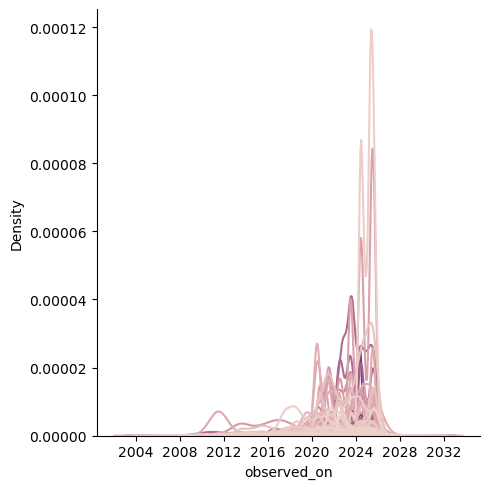

In [ ]:
plot_obs_dist(df_user, df)


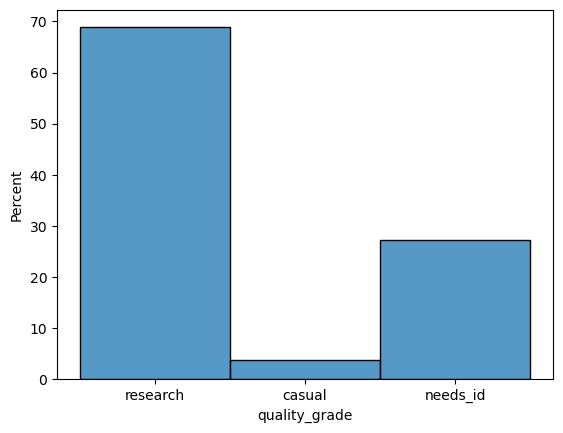

In [ ]:
plot_quality_dist(df_user, df)

In [ ]:
#Set half of data from maximum lower user sort 
target = 20000
df_user_low = df_user.sort_values('obs_count')
df_user_low

low_users =[]
count = 0

for index, row in df_user_low.iterrows():
    if count > target:
        break

    low_users.append(row['user_id'])
    count += row['obs_count']



df_user_low = df_user[df_user['user_id'].isin(low_users)]
print_df_user_stats(df_user_low)
print(df_user_low['obs_count'].mean())


Total observations: 20020 
Total users: 340
58.88235294117647
340


In [ ]:
df_user_low['sampling_pool'] = 'power_user'
df_user_low


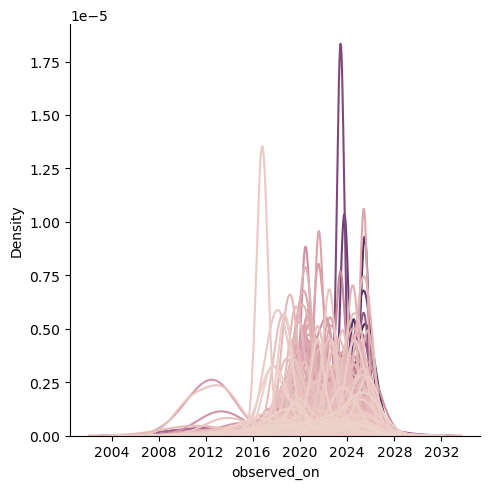

In [14]:
plot_obs_dist(df_user_low, df)


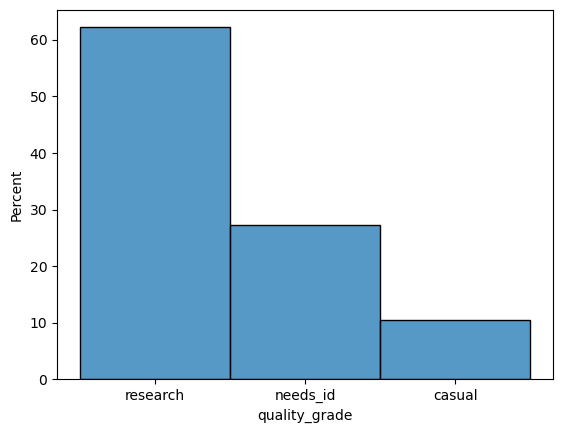

In [23]:
plot_quality_dist(df_user_low, df)

<Axes: xlabel='obs_count'>

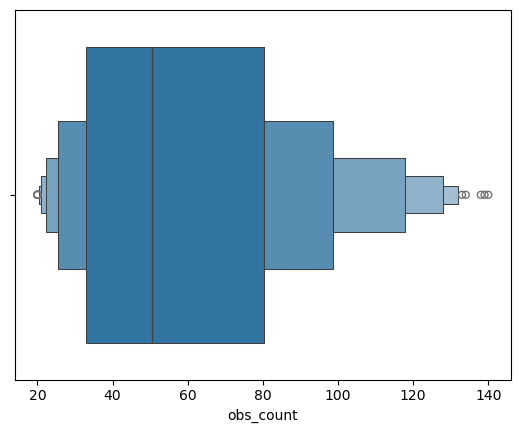

In [24]:
sns.boxenplot(df_user_low, x ='obs_count')

In [25]:
df_user_high = df_user[~df_user['user_id'].isin(low_users)]
df_user_high_obs = pd.merge(df, df_user_high, on=['user_id'], how='inner')
total = df_user_high_obs['id'].nunique()
split_percentage = target / total
print_df_user_stats(df_user_high)
print(total)
print(split_percentage)

Total observations: 257568 
Total users: 261
257566
0.07765000038825


In [26]:
# Create stratified col
df_user_high_obs['combined_col'] = df_user_high_obs['user_id'].astype(str) + "_" + df['quality_grade'].astype(str)
df_user_high_obs.dropna(inplace = True)
df_user_high_obs.shape[0]

256180

In [28]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df_user_high_obs, test_size=split_percentage,shuffle=True, stratify=df_user_high_obs['combined_col'], random_state=43)
df_test.shape[0]



19893

In [29]:
x = df_test['uuid'].to_list()
pprint(x[:10])

['676270ed-ae17-4aa6-aa06-29adab30a7fa',
 'fab04a1a-c662-4302-819d-6a0b1e0460a1',
 '434ad90e-b820-4e38-8fc3-31e6647a6a7e',
 'fafb1d07-003f-4a7b-8d1d-60b56e3299c4',
 'd2309374-d84c-4ccf-a21c-d312f471b85c',
 'e4ed6a21-591e-4311-b2c0-11683f21818e',
 '760bdd6a-a402-42f4-98ed-97529004c115',
 '96f3f91b-9bd8-4791-af78-0c4314ffac23',
 '823ea453-e0fb-418c-9d2b-935ed457de6c',
 '5600a532-e9ad-4ea2-a163-f3ebf0b1d620']


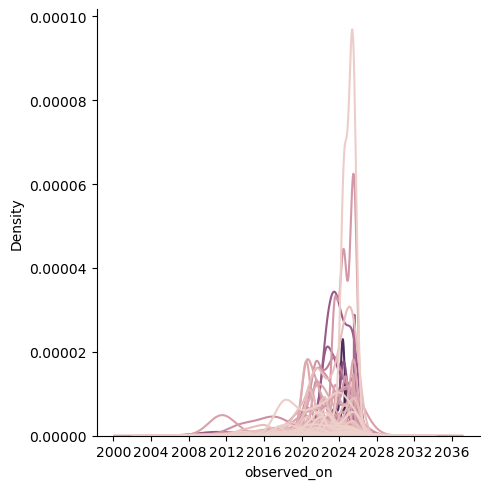

In [30]:
sns.displot(df_test, x = 'observed_on', kind ='kde', hue ='user_id', legend=False)

<Axes: xlabel='quality_grade', ylabel='Percent'>

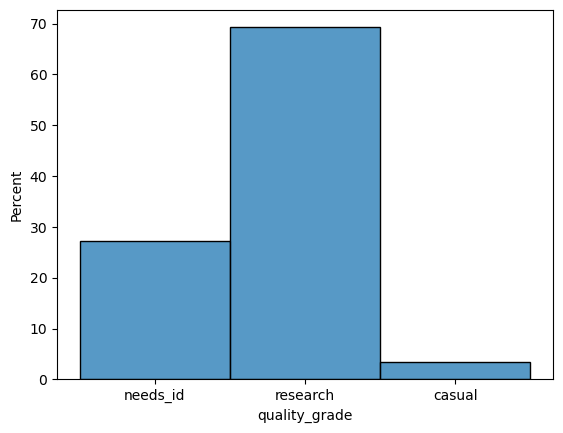

In [31]:
sns.histplot(df_test,x = 'quality_grade', stat ='percent', legend= True)

In [22]:
"""
df_monthly_obs = pd.merge(df, df_user, on='user_id', how='inner')
df_grouped = df.groupby(['user_id', df['observed_on'].dt.year.rename('year'), df['observed_on'].dt.month.rename('month')])['id'].count().reset_index('user_id', name ='count')
df_grouped.reset_index('year', inplace=True)
df_grouped.reset_index('month', inplace=True)
df_grouped = df_grouped[df_grouped['year'] <= 2020 ]
df_grouped
g = sns.relplot(data=df_grouped, x ='month', y='count', col= 'year', hue = 'user_id', col_wrap= 3, legend = False)
"""


"\ndf_monthly_obs = pd.merge(df, df_user, on='user_id', how='inner')\ndf_grouped = df.groupby(['user_id', df['observed_on'].dt.year.rename('year'), df['observed_on'].dt.month.rename('month')])['id'].count().reset_index('user_id', name ='count')\ndf_grouped.reset_index('year', inplace=True)\ndf_grouped.reset_index('month', inplace=True)\ndf_grouped = df_grouped[df_grouped['year'] <= 2020 ]\ndf_grouped\ng = sns.relplot(data=df_grouped, x ='month', y='count', col= 'year', hue = 'user_id', col_wrap= 3, legend = False)\n"